# Multi-agent training report

Per-learner learning curves and trained-vs-random checks for the CTDE run. Agents are
read from the saved curve, so this works for one agent (`--agents temperature`) or a
joint run (`--agents temperature routing`). Run `python -m training.train --agents ...`
first to produce the artifacts.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "training" / "config.py").exists():
            return candidate
    raise RuntimeError("project root not found (training/config.py)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training.config import COMPARE_SEED, CURVE_CSV, METRIC, env_config, load_agents
from env.training_env import ColdChainTrainingEnv
from training.evaluate import rollout
from training.agents import RandomAgent

curve = pd.read_csv(CURVE_CSV)
AGENTS = [c[len("return_"):] for c in curve.columns if c.startswith("return_")]

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
print("trained agents:", AGENTS)

trained agents: ['temperature', 'routing']


## Learning curves

Per learner: mean greedy return per episode (up = better) and its task metric
(down = better), over training iterations.

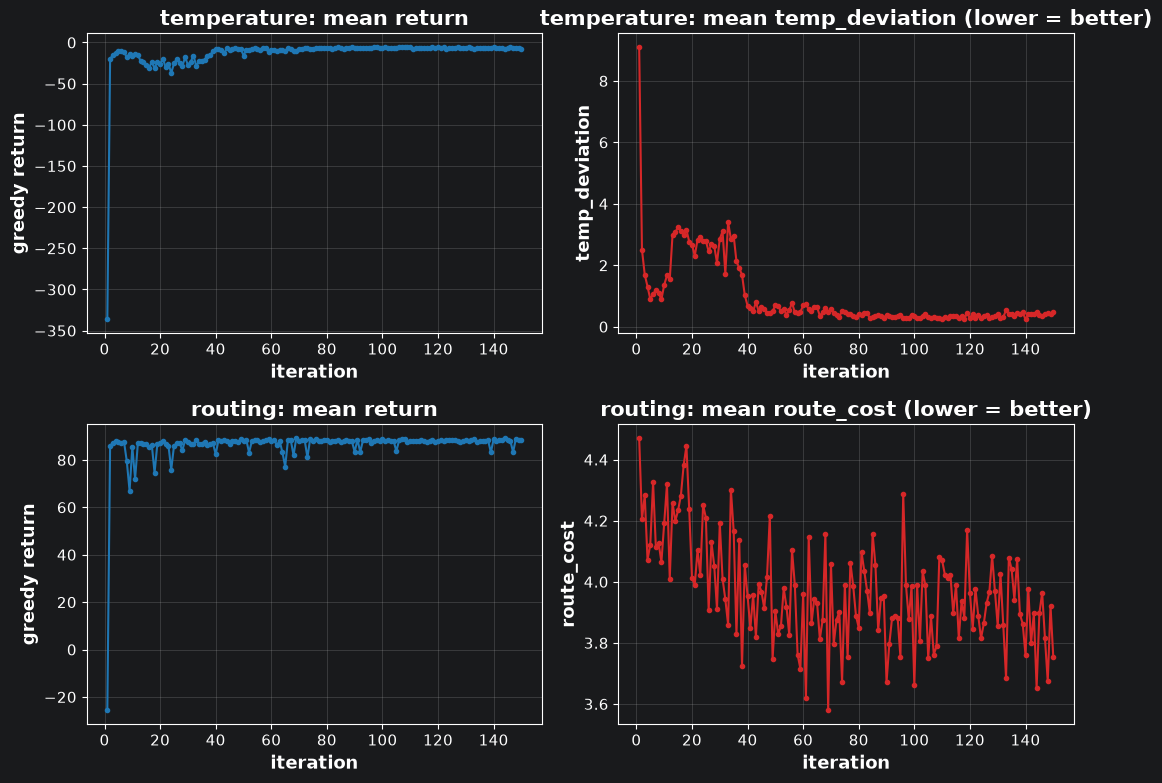

In [6]:
fig, axes = plt.subplots(len(AGENTS), 2, figsize=(11, 4 * len(AGENTS)), squeeze=False)
for i, a in enumerate(AGENTS):
    metric_key, direction = METRIC[a]
    goal = "lower = better" if direction == "min" else "higher = better"
    axes[i][0].plot(curve["iteration"], curve[f"return_{a}"], marker="o", ms=3, color="tab:blue")
    axes[i][0].set(title=f"{a}: mean return", xlabel="iteration", ylabel="greedy return")
    axes[i][1].plot(curve["iteration"], curve[f"{metric_key}_{a}"], marker="o", ms=3, color="tab:red")
    axes[i][1].set(title=f"{a}: mean {metric_key} ({goal})", xlabel="iteration", ylabel=metric_key)
fig.tight_layout()
plt.show()

## Trained vs random

Per learner: deterministic (greedy) trained policy vs a random one on a held-out seed
set; the other agents stay on their trained policies.

temperature: trained temp_deviation=0.433  random=10.866  (+96%)
routing: trained route_cost=3.898  random=4.327  (+10%)


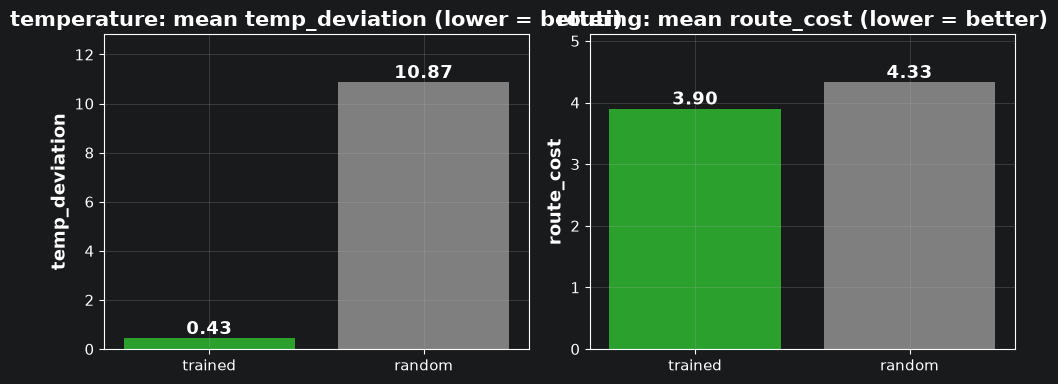

In [7]:
N_EPISODES = 40

fig, axes = plt.subplots(1, len(AGENTS), figsize=(5 * len(AGENTS), 4), squeeze=False)
for i, a in enumerate(AGENTS):
    metric_key, direction = METRIC[a]
    goal = "lower = better" if direction == "min" else "higher = better"

    # Fresh env per rollout so episode_index restarts at 0: trained and random
    # both see the same seed set (COMPARE_SEED .. COMPARE_SEED + N_EPISODES - 1).
    env = ColdChainTrainingEnv(env_config(COMPARE_SEED, AGENTS))
    trained = load_agents(env, AGENTS)
    _, trained_m = rollout(env, trained, a, N_EPISODES, metric_key)

    env = ColdChainTrainingEnv(env_config(COMPARE_SEED, AGENTS))
    rand = load_agents(env, AGENTS)
    rand[a] = RandomAgent(env.action_space(a))
    _, random_m = rollout(env, rand, a, N_EPISODES, metric_key)

    better = (random_m - trained_m) if direction == "min" else (trained_m - random_m)
    margin = better / abs(random_m) if random_m else float("nan")
    print(f"{a}: trained {metric_key}={trained_m:.3f}  random={random_m:.3f}  ({margin:+.0%})")

    ax = axes[0][i]
    ax.bar(["trained", "random"], [trained_m, random_m], color=["tab:green", "tab:gray"])
    ax.set(title=f"{a}: mean {metric_key} ({goal})", ylabel=metric_key)
    ax.margins(y=0.18)
    for j, v in enumerate([trained_m, random_m]):
        ax.text(j, v, f"{v:.2f}", ha="center", va="bottom", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()